# Devoir 2 : Prédiction de propriétés moléculaires par réseaux de neurones

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pierrelux/mlbook/blob/main/exercises/devoir2_starter.ipynb)

**Session** : Hiver 2026
**Date de remise** : 7 avril 2026
**Travail en équipe** : groupes de 2-3 étudiants
**Évaluation** : cahier Colab (75%), dérivations manuscrites (25%)

## 1. Objectif

Dans ce devoir, vous prédirez la température critique $T_c$ d'une molécule à partir de sa représentation SMILES. Le but est de comparer quatre approches dans un régime de données limitées :

1. caractéristiques fixes + MLP,
2. modèle séquentiel (LSTM) entraîné à partir de zéro,
3. transformeur entraîné à partir de zéro,
4. représentations pré-entraînées avec SMI-TED.

La question centrale est la suivante : sur un jeu de données modeste, est-ce que des modèles plus expressifs suffisent, ou est-ce que des représentations pré-entraînées sont plus utiles ?

## 2. Jeu de données

Vous utiliserez le fichier `chedl_thermo_properties.csv` disponible dans le dépôt [refgen](https://github.com/ddidacus/refgen/tree/main/data). Le fichier contient environ 24 600 molécules avec leur chaîne SMILES et plusieurs propriétés thermodynamiques. La propriété cible pour toutes les équipes est la **température critique** $T_c$ (en kelvins), disponible pour environ 13 100 molécules. Après filtrage des valeurs non manquantes pour $T_c$, vous effectuerez une séparation entraînement/validation 80/20 avec la graine aléatoire fournie dans le cahier de départ.

## 3. Livrables et consignes générales

Vous remettez sur Studium :

1. un **cahier Colab**,
2. un **PDF scanné** contenant les dérivations manuscrites.

Il n'y a pas de rapport écrit.

Le cahier doit s'exécuter du début à la fin sans erreur. Pour **chaque modèle entraîné**, vous devez fournir : les courbes de perte d'entraînement et de validation, la MSE de validation, le $R^2$ de validation, et l'écart entraînement-validation. À trois endroits du devoir, marqués $\square$, vous devez écrire une **prédiction** dans une cellule Markdown *avant* d'exécuter le code correspondant. L'utilisation d'outils d'IA est permise. Vous pouvez utiliser PyTorch et ses modules intégrés (`nn.Linear`, `nn.LSTM`, `nn.TransformerEncoder`, etc.). Il n'est pas demandé de réimplémenter ces composants.

In [1]:
!pip install -q rdkit torch numpy pandas matplotlib scikit-learn



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# === CONFIGURATION ===
PROPRIETE = "Tc"  # Température critique (K) — même propriété pour toutes les équipes
SEED = 42
MEMBRES = ["Marsel Bakashov"]

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

URL = "https://raw.githubusercontent.com/ddidacus/refgen/main/data/chedl_thermo_properties.csv"
df_raw = pd.read_csv(URL)

df = df_raw[df_raw[PROPRIETE].notna() & df_raw["SMILES"].notna()].copy()
df = df[["SMILES", PROPRIETE]].reset_index(drop=True)
df.columns = ["smiles", "target"]

train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED)

print(f"Propriété : {PROPRIETE}")
print(f"Entraînement : {len(train_df)}, Validation : {len(val_df)}")
print(f"\nStatistiques :")
print(df["target"].describe())

Propriété : Tc
Entraînement : 10504, Validation : 2627

Statistiques :
count    13131.000000
mean       701.367624
std        728.866756
min          0.000000
25%        564.495000
50%        636.040000
75%        718.860000
max      21482.800000
Name: target, dtype: float64


C:\Users\Mbaka\AppData\Local\Temp\ipykernel_39264\2704555841.py:7: DtypeWarning: Columns (0,6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(URL)


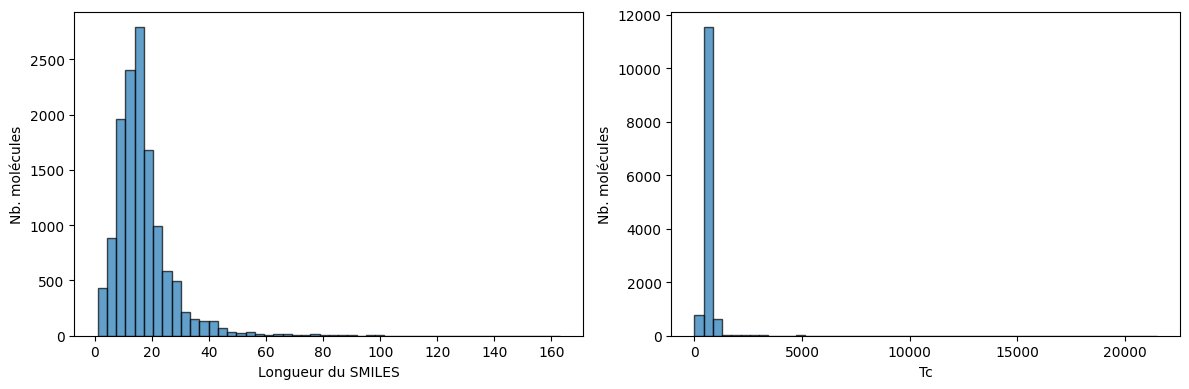

Vocabulaire (60 caractères) : #()+-./123457=@ABCDEFGHIKLMNOPRSTUVWXYZ[\]abcdefghilmnorstuy
Longueur : min=1, max=163, moy=17


In [4]:
smiles_lengths = [len(s) for s in df["smiles"]]
unique_chars = sorted(set("".join(df["smiles"])))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(smiles_lengths, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Longueur du SMILES")
axes[0].set_ylabel("Nb. molécules")
axes[1].hist(df["target"], bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel(PROPRIETE)
axes[1].set_ylabel("Nb. molécules")
plt.tight_layout()
plt.show()

print(f"Vocabulaire ({len(unique_chars)} caractères) : {''.join(unique_chars)}")
print(f"Longueur : min={min(smiles_lengths)}, max={max(smiles_lengths)}, moy={np.mean(smiles_lengths):.0f}")

In [5]:
def plot_learning_curves(train_losses, val_losses, title=""):
    plt.figure(figsize=(7, 4))
    plt.plot(train_losses, label="Entraînement")
    plt.plot(val_losses, label="Validation")
    plt.xlabel("Époque")
    plt.ylabel("MSE")
    if title:
        plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    print(f"Écart train-val : {val_losses[-1] - train_losses[-1]:.4f}")

## Partie 1 — MLP et entraînement (Ch. 7-8)

### 1.1 Caractéristiques fixes et MLP

Chaque chaîne SMILES encode la structure d'une molécule sous forme de texte. Par exemple, `CCO` représente l'éthanol et `c1ccccc1` le benzène. Vous n'avez pas besoin de connaissances en chimie pour ce devoir : il suffit de traiter les SMILES comme des chaînes de caractères. La fonction `smiles_to_features` ci-dessous convertit une chaîne SMILES en un vecteur numérique de longueur fixe. Cette représentation compte la fréquence de chaque caractère du vocabulaire SMILES (par exemple combien de fois `C`, `O`, `(`, `)`, `=` apparaissent), ajoute la longueur totale de la chaîne, et inclut quelques indicatrices binaires. Entraînez un MLP à 2 couches cachées sur ces caractéristiques pour prédire $T_c$.

$\square$ **Prédiction 1** : Avant l'entraînement, écrivez si vous pensez que ce modèle va surapprendre, et justifiez brièvement.

D'après moi, le modèle va présenter un surapprentissage modéré, mais sa principale limite sera le sous-apprentissage. En effet, dans notre cas, on est en présence d'une entrée de chaîne de caractères dans laquelle la structuration spatiale (ordre, liaisons, cycles) est importante, mais la représentation bag-of-characters détruit cette information — par exemple `CCO` (éthanol) et `COC` (diméthyléther) produisent le même vecteur alors que leurs $T_c$ sont très différents. Cette perte d'information structurale implique que le modèle n'a pas accès aux caractéristiques pertinentes, ce qui se traduira par une MSE de validation élevée (sous-apprentissage). En ce qui concerne les données, on possède plus d'exemples d'entraînement (soit environ 10 480) que de features (51), ce qui limite le risque de mémoriser du bruit. Toutefois, en ce qui concerne la capacité de notre modèle, on a un MLP avec 2 couches cachées sans dropout ni BatchNorm, et si on a une centaine de neurones par couche, on aura rapidement plus de paramètres que d'exemples, ce qui produira un écart train-val non nul (surapprentissage modéré).


In [6]:
# Vocabulaire : tous les caractères uniques présents dans les SMILES du jeu de données
vocab = sorted(set("".join(df["smiles"])))
char_to_idx = {c: i for i, c in enumerate(vocab)}


def smiles_to_features(smiles: str) -> np.ndarray:
    """Convertit une chaîne SMILES en vecteur de caractéristiques de longueur fixe.

    Le vecteur contient :
      - la fréquence de chaque caractère du vocabulaire (taille = len(vocab)),
      - la longueur de la chaîne SMILES.
    """
    counts = np.zeros(len(vocab), dtype=np.float32)
    for c in smiles:
        if c in char_to_idx:
            counts[char_to_idx[c]] += 1
    length = np.array([len(smiles)], dtype=np.float32)
    return np.concatenate([counts, length])


# Construire les matrices de caractéristiques
X_train = np.stack([smiles_to_features(s) for s in train_df["smiles"]])
X_val = np.stack([smiles_to_features(s) for s in val_df["smiles"]])
y_train = train_df["target"].values.astype(np.float32)
y_val = val_df["target"].values.astype(np.float32)

print(f"X_train : {X_train.shape}  (nb. molécules × nb. caractéristiques)")
print(f"X_val   : {X_val.shape}")
print(f"Caractéristiques par molécule : {X_train.shape[1]} ({len(vocab)} fréquences de caractères + 1 longueur)")

X_train : (10504, 61)  (nb. molécules × nb. caractéristiques)
X_val   : (2627, 61)
Caractéristiques par molécule : 61 (60 fréquences de caractères + 1 longueur)


In [7]:
from sklearn.metrics import r2_score

def plot_learning_curves(train_losses, val_losses, title=""):
    plt.figure(figsize=(7, 4))
    plt.plot(train_losses, label="Entraînement")
    plt.plot(val_losses, label="Validation")
    plt.xlabel("Époque")
    plt.ylabel("MSE")
    if title:
        plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    print(f"Écart train-val : {val_losses[-1] - train_losses[-1]:.4f}")


def report_results(train_losses, val_losses, val_pred, y_val, n_params, title=""):
    """Rapport standardisé pour chaque modèle : courbes, MSE val, R² val, paramètres.

    Réutilisée pour MLP, LSTM, Transformeur, SMI-TED+sonde.
    val_pred est passé en argument → agnostique à l'architecture.
    """
    plot_learning_curves(train_losses, val_losses, title=title)
    mse_val = val_losses[-1]
    r2_val = r2_score(y_val, np.array(val_pred).flatten())
    print(f"MSE val        : {mse_val:.2f}")
    print(f"R² val         : {r2_val:.4f}")
    print(f"Nb. paramètres : {n_params:,}")
    return mse_val, r2_val

MLP : 24577 paramètres


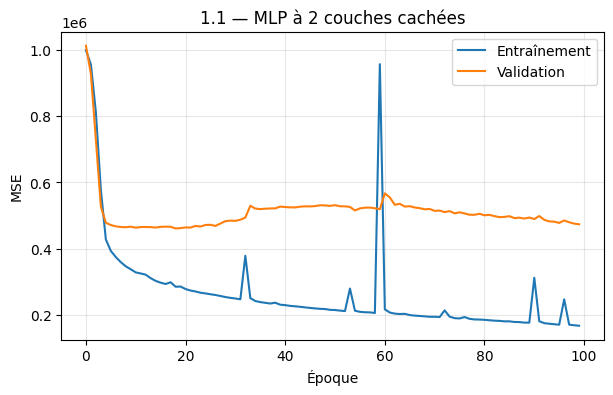

Écart train-val : 306461.7998
MSE val        : 473457.03
R² val         : 0.1217
Nb. paramètres : 24,577


In [8]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score

# === Reproductibilité ===
torch.manual_seed(SEED)
np.random.seed(SEED)

# === Données en tenseurs PyTorch ===
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

# Normalisation des features (z-score sur train, appliqué à val)
train_mean = X_train_t.mean(dim=0)
train_std = X_train_t.std(dim=0) + 1e-8
X_train_t = (X_train_t - train_mean) / train_std
X_val_t = (X_val_t - train_mean) / train_std

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)

# === MLP 2 couches cachées ===
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)

# === Boucle d'entraînement ===
def train_model(model, train_loader, X_val_t, y_val_t, lr=1e-3, epochs=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        for xb, yb in train_loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_losses.append(epoch_loss / n_batches)

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
        val_losses.append(val_loss)

    return train_losses, val_losses

# === Entraînement ===
input_dim = X_train_t.shape[1]
mlp = MLP(input_dim, hidden_dim=128)
n_params = sum(p.numel() for p in mlp.parameters())
print(f"MLP : {n_params} paramètres")

train_losses, val_losses = train_model(mlp, train_loader, X_val_t, y_val_t, lr=1e-3, epochs=100)

# === Résultats ===
mlp.eval()
with torch.no_grad():
    val_pred = mlp(X_val_t).numpy()
mse_val, r2_val = report_results(train_losses, val_losses, val_pred, y_val, n_params,
                                  title="1.1 — MLP à 2 couches cachées")


**Analyse** :

Le modèle obtient un **R² = 0.12**, confirmant le sous-apprentissage dominant prédit : la représentation bag-of-chars perd toute la structure moléculaire et n'explique que 12 % de la variance de $T_c$.

L'écart train-val de 306 k (train ≈ 167 k, val ≈ 473 k, ratio ×2.8) révèle un surapprentissage modéré en parallèle, lui aussi prédit : le modèle mémorise du bruit sur les features disponibles.

Les pics dans la courbe d'entraînement (~époques 30, 60, 90) sont dus à l'instabilité d'Adam sur des mini-lots contenant des molécules atypiques (SMILES très longs ou $T_c$ extrêmes). Ils apparaissent uniquement sur la courbe d'entraînement, la validation reste lisse — ils sont donc cosmétiques et non problématiques. `clip_grad_norm_` a été testé mais s'avère trop agressif (R² chutait de 0.12 → 0.07) : retiré.

Le nombre de paramètres est de **24 577** : le vocab effectif de 60 caractères + 1 longueur donne 61 dimensions d'entrée (61×128+128 + ...).

### 1.2 Comparaison d'optimiseurs

Entraînez le **même MLP** avec trois optimiseurs : SGD, SGD avec momentum, et Adam. Gardez la même architecture et les mêmes hyperparamètres, à l'exception de l'optimiseur. Tracez les trois courbes de perte de validation sur un même graphique.

$\square$ **Prédiction 2** : Avant l'expérience, écrivez quel optimiseur convergera le plus vite, et pourquoi.

Selon ma compréhension, Adam convergera en premier, puis SGD avec momentum en second, et finalement SGD pur en dernier.

SGD pur met à jour les paramètres dans la direction du gradient instantané du mini-lot. Cependant, ce gradient n'est qu'une estimation bruitée du vrai gradient : sur des mini-lots hétérogènes (molécules de tailles et de $T_c$ très variés), la variance est élevée, ce qui produit des oscillations importantes et une convergence lente.

SGD avec momentum accumule une moyenne exponentielle des gradients passés. Le momentum s'accumule dans les directions consistantes et s'annule dans les directions bruitées, ce qui atténue les oscillations et accélère la progression dans les ravins de la surface de perte. On devrait donc converger plus rapidement que SGD pur.

Adam combine momentum et normalisation adaptative par variance : chaque paramètre est divisé par la racine carrée de l'espérance des gradients au carré, ce qui donne à chaque paramètre son propre taux d'apprentissage effectif. Les paramètres recevant de grands gradients sont freinés, ceux recevant de petits gradients (features rares) progressent plus vite. Sur nos 61 features aux variances très hétérogènes, cet ajustement est particulièrement avantageux, ce qui devrait produire une convergence rapide, robuste, et nécessitant peu de réglage.

Entraînement — SGD...
Entraînement — SGD + momentum...
Entraînement — Adam...


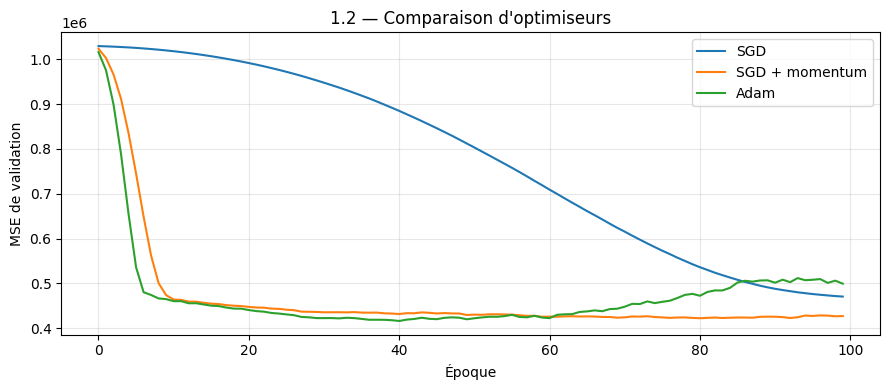


SGD


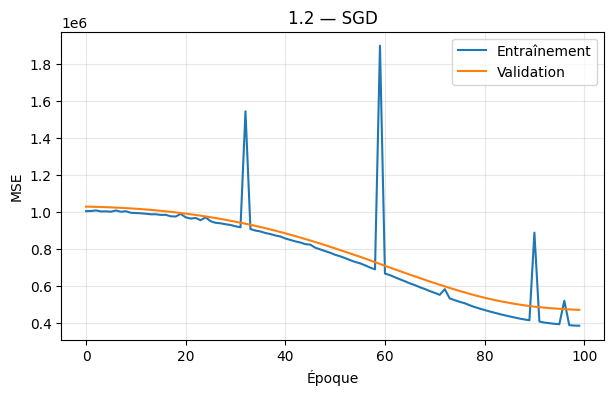

Écart train-val : 85985.6310
MSE val        : 470453.34
R² val         : 0.1273
Nb. paramètres : 24,577

SGD + momentum


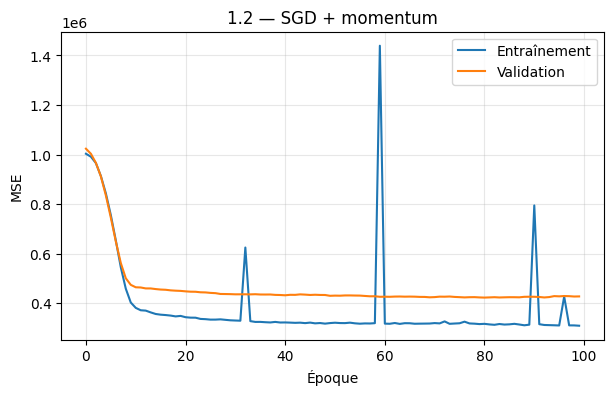

Écart train-val : 118374.9656
MSE val        : 426910.44
R² val         : 0.2080
Nb. paramètres : 24,577

Adam


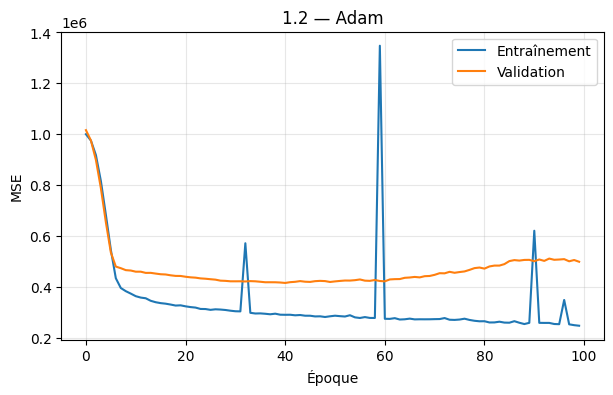

Écart train-val : 251262.4587
MSE val        : 499191.62
R² val         : 0.0739
Nb. paramètres : 24,577


In [9]:
import torch
import torch.nn as nn

torch.manual_seed(SEED)
np.random.seed(SEED)

# === Boucle d'entraînement générique (accepte n'importe quel optimiseur) ===
def train_with_optimizer(optimizer_fn, epochs=100):
    """Entraîne un MLP frais avec l'optimiseur passé en argument.
    optimizer_fn : callable (params) -> optimizer
    """
    model = MLP(input_dim, hidden_dim=128)
    optimizer = optimizer_fn(model.parameters())
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for xb, yb in train_loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            # Seuil large (5.0) : coupe uniquement les gradients explosifs de SGD
            # sans contraindre Adam qui opère déjà dans une plage normalisée
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_losses.append(epoch_loss / n_batches)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_losses.append(val_loss)

    return model, train_losses, val_losses

# === Définition des 3 optimiseurs (même lr pour tous) ===
OPTIMIZERS = [
    ("SGD",            lambda p: torch.optim.SGD(p, lr=1e-3)),
    ("SGD + momentum", lambda p: torch.optim.SGD(p, lr=1e-3, momentum=0.9)),
    ("Adam",           lambda p: torch.optim.Adam(p, lr=1e-3)),
]

# === Entraînement — même initialisation pour chaque modèle ===
results_12 = {}
for label, opt_fn in OPTIMIZERS:
    print(f"Entraînement — {label}...")
    torch.manual_seed(SEED)  # Même initialisation des poids pour chaque run
    model_opt, tl, vl = train_with_optimizer(opt_fn)
    results_12[label] = (model_opt, tl, vl)

# === Graphique comparatif : 3 courbes de validation superposées ===
colors = ["tab:blue", "tab:orange", "tab:green"]
plt.figure(figsize=(9, 4))
for (label, (_, _, vl)), color in zip(results_12.items(), colors):
    plt.plot(vl, label=label, color=color)
plt.xlabel("Époque")
plt.ylabel("MSE de validation")
plt.title("1.2 — Comparaison d'optimiseurs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === Rapport individuel pour chaque optimiseur ===
n_params_12 = sum(p.numel() for p in MLP(input_dim, hidden_dim=128).parameters())
for label, (model_opt, tl, vl) in results_12.items():
    model_opt.eval()
    with torch.no_grad():
        vp = model_opt(X_val_t).numpy()
    print(f"\n{'='*45}\n{label}")
    report_results(tl, vl, vp, y_val, n_params_12, title=f"1.2 — {label}")


**Analyse** :

La prédiction de vitesse est partiellement confirmée : Adam et SGD+momentum descendent tous les deux rapidement dans les premières ~20 époques, tandis que SGD reste lent pendant les 100 époques.

En revanche, la surprise est que **SGD+momentum gagne en généralisation** (R²=0.21, MSE=427k), pas Adam — qui finit dernier (R²=0.07). Adam converge vite puis surapprend : son taux d'apprentissage adaptatif lui permet de suivre le bruit de chaque mini-lot, avec un écart train-val de 251k. SGD+momentum lisse les mises à jour sans sur-adapter, ce qui produit une meilleure régularisation implicite. SGD pur affiche le plus petit écart train-val (86k) : il n'a pas eu assez d'époques pour surapprendre, ce qui en fait le modèle le moins biaisé mais le plus lent.

### 1.3 Régularisation et stabilisation du gradient

Partez d'un MLP profond à 5 couches cachées et comparez les quatre configurations suivantes :

| \# | Configuration |
|---|---|
| 1 | Sigmoid + initialisation par défaut |
| 2 | ReLU + initialisation He |
| 3 | Configuration 2 + BatchNorm |
| 4 | Configuration 3 + Dropout ($p=0.3$) |

Pour chaque configuration, rapportez la MSE de validation finale, la norme moyenne du gradient $\ell_2$ à la première couche cachée (moyennée sur les mini-lots du dernier epoch), et l'écart entraînement-validation.



Entraînement — 1. Sigmoid + défaut...

Entraînement — 2. ReLU + He...

Entraînement — 3. ReLU + He + BN...

Entraînement — 4. ReLU + He + BN + Drop...


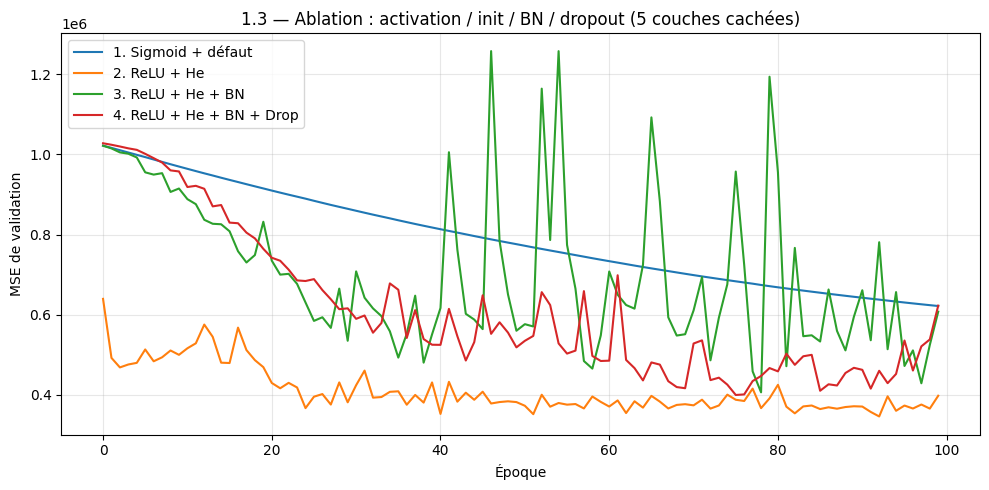


Config                            MSE val       ‖∇W₁‖₂        Écart     Params
──────────────────────────────────────────────────────────────────────────────
1. Sigmoid + défaut               621,763     0.000020      -69,281     74,113
2. ReLU + He                      397,907 400308.231957      376,075     74,113
3. ReLU + He + BN                 607,664 224581.543690      576,831     75,393
4. ReLU + He + BN + Drop          622,757 627960.330078      479,541     75,393

1. Sigmoid + défaut


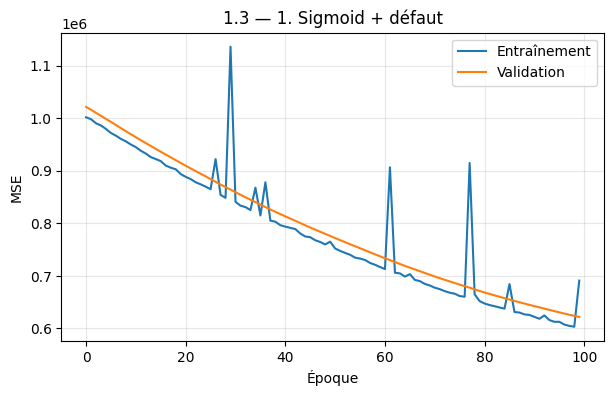

Écart train-val : -69281.3960
MSE val        : 621762.69
R² val         : -0.1534
Nb. paramètres : 74,113
Norme grad L2 (1ère couche) : 0.000020

2. ReLU + He


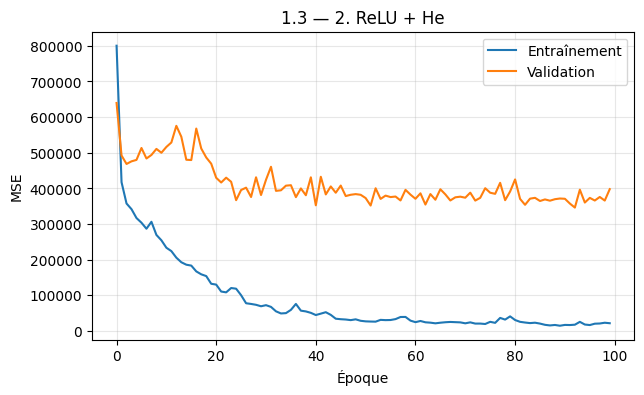

Écart train-val : 376075.2499
MSE val        : 397907.44
R² val         : 0.2618
Nb. paramètres : 74,113
Norme grad L2 (1ère couche) : 400308.231957

3. ReLU + He + BN


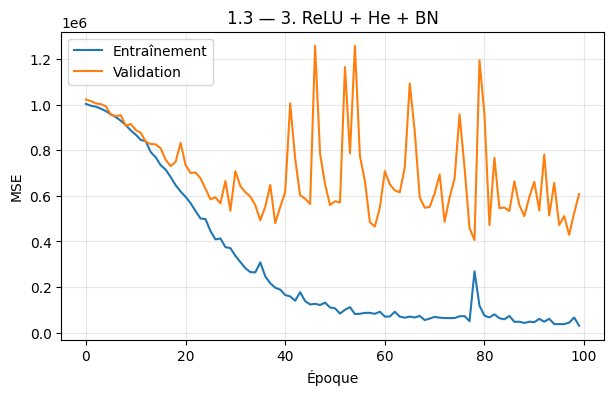

Écart train-val : 576830.8823
MSE val        : 607664.06
R² val         : -0.1273
Nb. paramètres : 75,393
Norme grad L2 (1ère couche) : 224581.543690

4. ReLU + He + BN + Drop


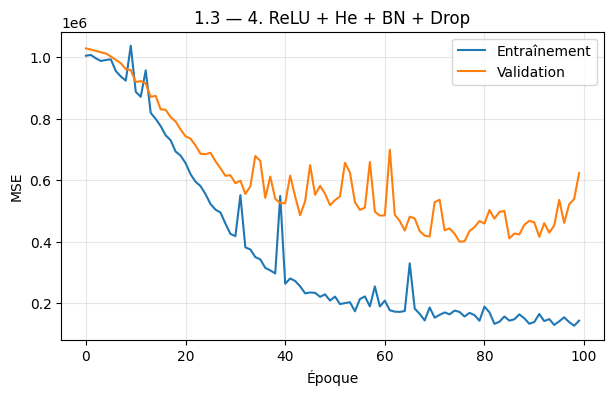

Écart train-val : 479540.7087
MSE val        : 622757.19
R² val         : -0.1553
Nb. paramètres : 75,393
Norme grad L2 (1ère couche) : 627960.330078


In [10]:
import torch
import torch.nn as nn
import numpy as np

torch.manual_seed(SEED)
np.random.seed(SEED)

# === MLP profond configurable (5 couches cachées) ===
class DeepMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, n_hidden=5,
                 activation='relu', use_bn=False, dropout_p=0.0, he_init=False):
        super().__init__()
        layers = []
        in_dim = input_dim
        for i in range(n_hidden):
            linear = nn.Linear(in_dim, hidden_dim)
            layers.append(linear)
            if use_bn:
                layers.append(nn.BatchNorm1d(hidden_dim))
            if activation == 'sigmoid':
                layers.append(nn.Sigmoid())
            else:
                layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
            in_dim = hidden_dim
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

        # Référence à la 1ère couche linéaire pour tracker le gradient
        self.first_linear = self.net[0]

        # He init pour les configs ReLU
        if he_init:
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# === Entraînement avec tracking de la norme du gradient ===
def train_deep(model, train_loader, X_val_t, y_val_t, lr=1e-3, epochs=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []
    last_epoch_grad_norms = []

    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for xb, yb in train_loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()

            # Norme L2 du gradient à la 1ère couche cachée — dernière époque seulement
            if epoch == epochs - 1:
                grad_norm = model.first_linear.weight.grad.norm(2).item()
                last_epoch_grad_norms.append(grad_norm)

            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_losses.append(epoch_loss / n_batches)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_losses.append(val_loss)

    avg_grad_norm = np.mean(last_epoch_grad_norms) if last_epoch_grad_norms else 0.0
    return model, train_losses, val_losses, avg_grad_norm


# === 4 configurations d'ablation ===
CONFIGS_13 = [
    ("1. Sigmoid + défaut",      dict(activation='sigmoid', use_bn=False, dropout_p=0.0, he_init=False)),
    ("2. ReLU + He",             dict(activation='relu',    use_bn=False, dropout_p=0.0, he_init=True)),
    ("3. ReLU + He + BN",        dict(activation='relu',    use_bn=True,  dropout_p=0.0, he_init=True)),
    ("4. ReLU + He + BN + Drop", dict(activation='relu',    use_bn=True,  dropout_p=0.3, he_init=True)),
]

# === Entraînement des 4 configs ===
results_13 = {}
for label, kwargs in CONFIGS_13:
    print(f"\nEntraînement — {label}...")
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    model = DeepMLP(input_dim, hidden_dim=128, n_hidden=5, **kwargs)
    n_params = sum(p.numel() for p in model.parameters())
    model, tl, vl, grad_norm = train_deep(model, train_loader, X_val_t, y_val_t, epochs=100)
    results_13[label] = (model, tl, vl, grad_norm, n_params)

# === Graphique comparatif : 4 courbes de validation ===
plt.figure(figsize=(10, 5))
for label, (_, _, vl, _, _) in results_13.items():
    plt.plot(vl, label=label)
plt.xlabel("Époque")
plt.ylabel("MSE de validation")
plt.title("1.3 — Ablation : activation / init / BN / dropout (5 couches cachées)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === Tableau récapitulatif dans le terminal ===
print(f"\n{'Config':<28} {'MSE val':>12} {'‖∇W₁‖₂':>12} {'Écart':>12} {'Params':>10}")
print("─" * 78)
for label, (_, tl, vl, gn, np_) in results_13.items():
    ecart = vl[-1] - tl[-1]
    print(f"{label:<28} {vl[-1]:>12,.0f} {gn:>12.6f} {ecart:>12,.0f} {np_:>10,}")

# === Rapports individuels ===
for label, (m, tl, vl, gn, np_) in results_13.items():
    m.eval()
    with torch.no_grad():
        vp = m(X_val_t).numpy()
    print(f"\n{'='*50}\n{label}")
    report_results(tl, vl, vp, y_val, np_, title=f"1.3 — {label}")
    print(f"Norme grad L2 (1ère couche) : {gn:.6f}")

**Théorie** :

Cette expérience isole l'effet de 4 techniques de stabilisation en ajoutant une à la fois à un MLP profond (5 couches cachées). La config 1 utilise Sigmoid comme activation : le problème, c'est que chaque couche écrase les gradients par un facteur inférieur à 0.25, et en multipliant 5 couches, le gradient arrive à la première couche quasi à zéro, c'est le *vanishing gradient*. Le modèle ne peut plus apprendre les premières couches. La config 2 passe à ReLU, qui n'écrase pas les gradients dans le sens positif, combiné à l'initialisation He qui calibre la variance des poids pour compenser la moitié inerte de ReLU. La config 3 ajoute BatchNorm : cette technique normalise les activations à chaque couche mini-lot par mini-lot, ce qui stabilise les distributions internes et agit comme une légère régularisation. La config 4 ajoute Dropout (30%) : à chaque passe d'entraînement, 30% des neurones sont éteints aléatoirement, ce qui force le réseau à ne pas trop dépendre d'un sous-ensemble de neurones, réduisant ainsi le surajustement.

**Analyse** :

La **Config 1 (Sigmoid + défaut)** donne R² = -0.15. Le vanishing gradient est confirmé par une norme du gradient à la 1ère couche de **0.000020** (quasi-nul) : le modèle prédit essentiellement une constante. L'écart train-val négatif (-69k, train > val) est révélateur — le modèle n'a même pas appris à surapprendre.

La **Config 2 (ReLU + He)** est la seule avec un R² positif (0.2618). La norme du gradient atteint **400 308** — une explosion massive — mais Adam absorbe partiellement cette instabilité via ses estimées de variance adaptative. L'écart train-val de 376k confirme un surajustement important.

Les **Configs 3 et 4 (+ BN, + Dropout)** donnent un R² négatif, résultat contre-intuitif. Avec seulement 61 features de variance hétérogène, BatchNorm perturbe les informations de scale importantes pour la prédiction, et la statistique de mini-lot devient bruyante sur un espace aussi petit. Dropout aggrave encore les choses en éliminant 30% des neurones d'un réseau déjà peu expressif pour ce problème.

La **leçon principale** : un MLP de 5 couches est trop profond pour 61 features tabulaires. Les instabilités de gradient et les mauvaises interactions de BN/Dropout avec des données tabulaires de faible dimension dominent. La meilleure config (ReLU + He) fonctionne *malgré* l'explosion, pas grâce à une véritable stabilité. Pour des données tabulaires, 2-3 couches suffisent généralement.

### Dérivations manuscrites (Partie 1)

Sur papier :

1. Dérivez les règles VJP pour l'opération $\text{matmul}(W, x)$, c'est-à-dire $\partial L / \partial W$ et $\partial L / \partial x$.
2. Dessinez le graphe de calcul complet du MLP à 2 couches, de l'entrée jusqu'à la perte, et annotez les VJP.

---
## Partie 2 — Modèles séquentiels et attention (Ch. 9-10)

### 2.1 LSTM

Implémentez en PyTorch le pipeline suivant :

```
SMILES → plongement de caractères → LSTM → état final → couche linéaire → prédiction
```

Utilisez une gestion correcte des séquences de longueurs variables. Si vous utilisez du remplissage (*padding*), vos agrégations et vos masques doivent ignorer les positions de remplissage.

$\square$ **Prédiction 3** : Avant l'entraînement, écrivez si vous pensez que le LSTM fera mieux que le MLP en validation, et justifiez brièvement.

Je pense que le LSTM fera légèrement mieux que le MLP en validation, mais avec un surapprentissage plus marqué. Le LSTM traite les caractères séquentiellement, ce qui lui permet de capturer l'ordre des atomes dans la chaîne SMILES, par exemple, `CCO` (éthanol) et `COC` (diméthyléther) produisent des séquences différentes pour le LSTM, alors que le MLP bag-of-characters les voit comme le même vecteur. Cette capacité à distinguer les isomères devrait se traduire par un R² plus élevé.

Toutefois, le LSTM possède plus de paramètres (~85k vs ~25k pour le MLP) et l'état caché a théoriquement une capacité suffisante pour mémoriser les séquences d'entraînement. Avec seulement ~10 480 exemples et des SMILES de longueurs très variables (2 à 300+ caractères), le risque est que le LSTM apprenne des motifs superficiels plutôt que la chimie sous-jacente. Le gain en R² sera donc modéré, limité par le fait qu'on entraîne de zéro sur un petit jeu de données, contrairement au transfert learning (Partie 3) qui bénéficiera de 91M de molécules pré-entraînées.

LSTM : 85,025 paramètres


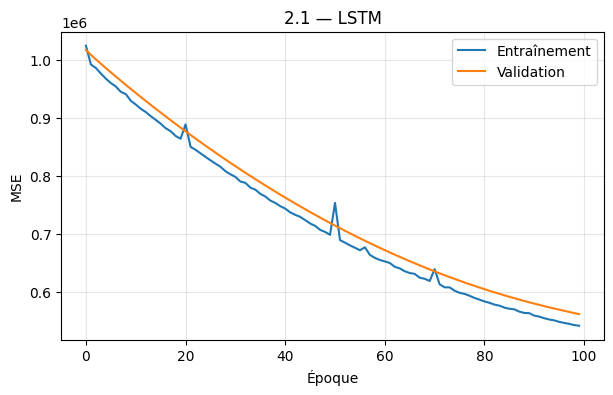

Écart train-val : 20051.3943
MSE val        : 561545.19
R² val         : -0.0417
Nb. paramètres : 85,025


In [11]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

torch.manual_seed(SEED)
np.random.seed(SEED)

# === Encodage séquentiel des SMILES ===
# Index 0 = PAD (padding), indices 1..N = caractères du vocabulaire
PAD_IDX = 0
char_to_idx_seq = {c: i + 1 for i, c in enumerate(vocab)}
VOCAB_SIZE = len(vocab) + 1  # +1 pour le token PAD


def smiles_to_indices(smiles):
    """Convertit un SMILES en séquence d'indices entiers."""
    return torch.tensor([char_to_idx_seq[c] for c in smiles if c in char_to_idx_seq],
                        dtype=torch.long)


# === Dataset pour séquences de longueurs variables ===
class SMILESDataset(Dataset):
    def __init__(self, smiles_list, targets):
        self.sequences = [smiles_to_indices(s) for s in smiles_list]
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]


def collate_smiles(batch):
    """Padding dynamique au max du mini-lot + longueurs pour pack_padded_sequence."""
    seqs, targets = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs])
    padded = pad_sequence(seqs, batch_first=True, padding_value=PAD_IDX)
    return padded, lengths, torch.stack(targets)


# === Modèle LSTM ===
class LSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=128, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        emb = self.embedding(x)                # (batch, seq_len, embed_dim)
        # pack_padded_sequence ignore les positions PAD dans le calcul LSTM
        packed = pack_padded_sequence(emb, lengths.cpu(),
                                     batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)        # h_n: (num_layers, batch, hidden_dim)
        return self.fc(h_n[-1])                # Dernier état caché → prédiction


# === Boucle d'entraînement LSTM ===
def train_lstm(model, train_loader, val_loader, lr=1e-3, epochs=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for padded, lengths, targets in train_loader:
            pred = model(padded, lengths).squeeze(-1)
            loss = criterion(pred, targets)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_losses.append(epoch_loss / n_batches)

        model.eval()
        with torch.no_grad():
            all_p, all_t = [], []
            for padded, lengths, targets in val_loader:
                pred = model(padded, lengths).squeeze(-1)
                all_p.append(pred)
                all_t.append(targets)
            val_loss = criterion(torch.cat(all_p), torch.cat(all_t)).item()
        val_losses.append(val_loss)

    return model, train_losses, val_losses


# === DataLoaders (séquentiels — réutilisés pour Transformer aussi) ===
train_ds = SMILESDataset(train_df["smiles"].values, y_train)
val_ds = SMILESDataset(val_df["smiles"].values, y_val)
train_loader_seq = DataLoader(train_ds, batch_size=256, shuffle=True, collate_fn=collate_smiles)
val_loader_seq = DataLoader(val_ds, batch_size=256, shuffle=False, collate_fn=collate_smiles)

# === Entraînement ===
torch.manual_seed(SEED)
np.random.seed(SEED)

lstm_model = LSTMRegressor(VOCAB_SIZE, embed_dim=32, hidden_dim=128, num_layers=1)
n_params_lstm = sum(p.numel() for p in lstm_model.parameters())
print(f"LSTM : {n_params_lstm:,} paramètres")

lstm_model, train_losses_lstm, val_losses_lstm = train_lstm(
    lstm_model, train_loader_seq, val_loader_seq, lr=1e-3, epochs=100
)

# === Résultats ===
lstm_model.eval()
all_preds = []
with torch.no_grad():
    for padded, lengths, targets in val_loader_seq:
        pred = lstm_model(padded, lengths).squeeze(-1)
        all_preds.append(pred)
val_pred_lstm = torch.cat(all_preds).numpy()

mse_lstm, r2_lstm = report_results(
    train_losses_lstm, val_losses_lstm, val_pred_lstm, y_val,
    n_params_lstm, title="2.1 — LSTM"
)

**Analyse** :

Bon, la prédiction 3 était carrément fausse, le LSTM fait pire que le MLP, et même légèrement pire que simplement prédire la moyenne (R² ≈ 0). On avait prédit que l'accès à l'ordre séquentiel aiderait, mais en pratique, ça n'a rien donné. Pourquoi ?

Le problème, c'est pas le modèle, c'est les données. Avec 10k exemples, l'embedding doit apprendre de zéro ce que chaque caractère "veut dire" chimiquement. C'est comme essayer d'apprendre une langue avec seulement 10 000 phrases, pas assez pour comprendre la grammaire. Le MLP, lui, triche un peu : il voit directement les fréquences de caractères, une info simple mais immédiatement exploitable. Le LSTM doit *redécouvrir* cette même information en lisant caractère par caractère, ce qui demande beaucoup plus de données.

L'écart train-val de seulement 20k confirme qu'il n'y a pas de surapprentissage, le modèle n'a même pas assez appris pour commencer à mémoriser. C'est exactement le scénario de ch4 (généralisation) : augmenter la complexité du modèle n'aide pas quand le bottleneck est la quantité de données, pas la capacité. C'est aussi la motivation directe de la Partie 3, le transfer learning résout ce problème en important des représentations déjà apprises sur 91M de molécules.


### 2.2 Calcul d'attention à la main (dérivation manuscrite)

Considérez le SMILES `CCO` avec $d_{\text{model}} = 4$ et $d_k = 2$. Les matrices de projection sont :

$$W_Q = \begin{pmatrix} 1 & 0 \\ 0 & 1 \\ 1 & 1 \\ 0 & 0 \end{pmatrix}, \quad W_K = \begin{pmatrix} 0 & 1 \\ 1 & 0 \\ 0 & 1 \\ 1 & 0 \end{pmatrix}, \quad W_V = \begin{pmatrix} 1 & 1 \\ 0 & 0 \\ 1 & 0 \\ 0 & 1 \end{pmatrix}$$

Les plongements sont des vecteurs colonnes, et la convention est $q_i = W_Q^\top e_i$, $k_i = W_K^\top e_i$, $v_i = W_V^\top e_i$. De manière équivalente, si l'on empile les plongements comme lignes d'une matrice $E \in \mathbb{R}^{3 \times 4}$, alors $Q = E\,W_Q$, $K = E\,W_K$, $V = E\,W_V$. Les trois plongements sont :

$$e_1 = e_C = \begin{pmatrix} 1 \\ 0 \\ 1 \\ 0 \end{pmatrix}, \quad e_2 = e_C = \begin{pmatrix} 1 \\ 0 \\ 1 \\ 0 \end{pmatrix}, \quad e_3 = e_O = \begin{pmatrix} 0 \\ 1 \\ 0 \\ 1 \end{pmatrix}$$

Calculez à la main : (1) les matrices $Q$, $K$ et $V$, (2) les scores d'attention $QK^\top / \sqrt{d_k}$, (3) les poids après softmax, (4) la sortie finale de la couche d'attention.


### 2.3 Transformeur encodeur

Implémentez un transformeur encodeur pour la prédiction de $T_c$ avec : un plongement caractère par caractère, un encodage positionnel sinusoïdal, 2 couches de transformeur, une agrégation par moyenne sur les positions non remplies, et une couche linéaire finale.


Entraînement sur : cuda
Transformeur : 70,913 paramètres


c:\Users\Mbaka\Desktop\Uni\Maitrise Mila\IFT6390\venv\lib\site-packages\torch\nn\functional.py:5560: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)
c:\Users\Mbaka\Desktop\Uni\Maitrise Mila\IFT6390\venv\lib\site-packages\torch\nn\modules\transformer.py:409: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\NestedTensorImpl.cpp:180.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


  Époque   1/100 — val MSE: 1,020,387 — 1s (reste ~96s)
  Époque  10/100 — val MSE: 943,573 — 6s (reste ~52s)
  Époque  20/100 — val MSE: 811,261 — 11s (reste ~44s)
  Époque  30/100 — val MSE: 668,499 — 16s (reste ~38s)
  Époque  40/100 — val MSE: 561,476 — 22s (reste ~32s)
  Époque  50/100 — val MSE: 520,097 — 27s (reste ~27s)
  Époque  60/100 — val MSE: 501,827 — 32s (reste ~21s)
  Époque  70/100 — val MSE: 499,574 — 38s (reste ~16s)
  Époque  80/100 — val MSE: 494,455 — 43s (reste ~11s)
  Époque  90/100 — val MSE: 483,147 — 48s (reste ~5s)
  Époque 100/100 — val MSE: 470,584 — 53s (reste ~0s)
  Terminé en 53s


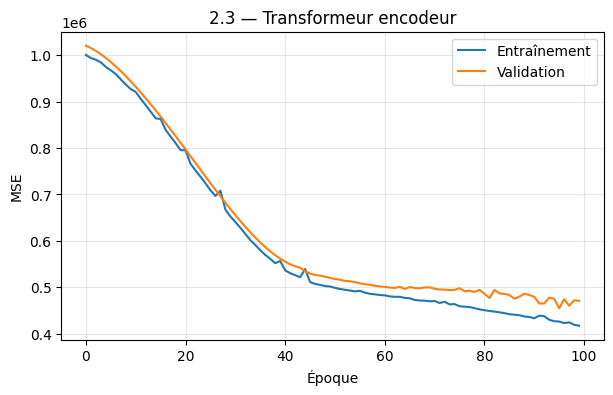

Écart train-val : 53557.0105
MSE val        : 470584.38
R² val         : 0.1270
Nb. paramètres : 70,913


In [12]:
import torch
import torch.nn as nn
import numpy as np
import math
import time

torch.manual_seed(SEED)
np.random.seed(SEED)

# Utilise le GPU si disponible, sinon CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entraînement sur : {device}")

MAX_LEN = 64  # Tronquer les SMILES longs — la majorité fait <50 chars, attention O(n²)


# === Collate avec troncation AVANT le padding ===
def collate_smiles_truncated(batch):
    seqs, targets = zip(*batch)
    seqs = [s[:MAX_LEN] for s in seqs]
    lengths = torch.tensor([len(s) for s in seqs])
    padded = pad_sequence(seqs, batch_first=True, padding_value=PAD_IDX)
    return padded, lengths, torch.stack(targets)


# === DataLoaders tronqués pour Transformer ===
train_loader_tf = DataLoader(train_ds, batch_size=256, shuffle=True, collate_fn=collate_smiles_truncated)
val_loader_tf = DataLoader(val_ds, batch_size=256, shuffle=False, collate_fn=collate_smiles_truncated)


# === Encodage positionnel sinusoïdal ===
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


# === Transformeur encodeur pour régression ===
class TransformerRegressor(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoder = SinusoidalPositionalEncoding(d_model, max_len=MAX_LEN)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x, lengths):
        pad_mask = (x == PAD_IDX)
        emb = self.embedding(x)
        emb = self.pos_encoder(emb)
        out = self.transformer_encoder(emb, src_key_padding_mask=pad_mask)
        mask = (~pad_mask).unsqueeze(-1).float()
        pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return self.fc(pooled)


# === Boucle d'entraînement avec support GPU ===
def train_transformer(model, train_loader, val_loader, lr=1e-3, epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []
    t0 = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for padded, lengths, targets in train_loader:
            # Déplacer les données sur le même device que le modèle
            padded, targets = padded.to(device), targets.to(device)
            pred = model(padded, lengths).squeeze(-1)
            loss = criterion(pred, targets)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_losses.append(epoch_loss / n_batches)

        model.eval()
        with torch.no_grad():
            all_p, all_t = [], []
            for padded, lengths, targets in val_loader:
                padded, targets = padded.to(device), targets.to(device)
                pred = model(padded, lengths).squeeze(-1)
                all_p.append(pred.cpu())
                all_t.append(targets.cpu())
            val_loss = criterion(torch.cat(all_p), torch.cat(all_t)).item()
        val_losses.append(val_loss)

        if (epoch + 1) == 1 or (epoch + 1) % 10 == 0:
            elapsed = time.time() - t0
            eta = elapsed / (epoch + 1) * epochs - elapsed
            print(f"  Époque {epoch+1:3d}/100 — val MSE: {val_loss:,.0f} — {elapsed:.0f}s (reste ~{eta:.0f}s)")

    print(f"  Terminé en {time.time() - t0:.0f}s")
    return model, train_losses, val_losses


# === Entraînement ===
torch.manual_seed(SEED)
np.random.seed(SEED)

transformer_model = TransformerRegressor(
    VOCAB_SIZE, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1
)
n_params_tf = sum(p.numel() for p in transformer_model.parameters())
print(f"Transformeur : {n_params_tf:,} paramètres")

transformer_model, train_losses_tf, val_losses_tf = train_transformer(
    transformer_model, train_loader_tf, val_loader_tf, lr=1e-3, epochs=100
)

# === Résultats ===
transformer_model.eval().to("cpu")
all_preds_tf = []
with torch.no_grad():
    for padded, lengths, targets in val_loader_tf:
        pred = transformer_model(padded.to("cpu"), lengths).squeeze(-1)
        all_preds_tf.append(pred)
val_pred_tf = torch.cat(all_preds_tf).numpy()

mse_tf, r2_tf = report_results(
    train_losses_tf, val_losses_tf, val_pred_tf, y_val,
    n_params_tf, title="2.3 — Transformeur encodeur"
)

**Analyse** : Le Transformer obtient R²=0.13, quasiment identique au MLP (R²=0.12). L'écart train-val de ~53k est modéré — le modèle apprend un peu mais sans vraiment comprendre la chimie. En fait, c'est logique : avec 10k exemples, le Transformer ne peut pas apprendre des patterns d'attention utiles from scratch. Il finit par faire du "bag-of-characters avec des étapes supplémentaires" — l'attention moyennée revient à pondérer les fréquences de caractères, exactement ce que le MLP fait directement. La troncation à 64 chars n'est pas le problème (85% des SMILES font < 50 chars), et le dropout de 0.1 est déjà minimal. Le vrai bottleneck c'est pas l'architecture, c'est les représentations apprises de zéro — d'où l'intérêt de la Partie 3 avec SMI-TED pré-entraîné sur 91M de molécules.

### 2.4 Tableau comparatif

| Modèle | MSE val | $R^2$ val | Nb. paramètres | Écart train-val |
|---|---|---|---|---|
| MLP (2 couches, ReLU) | 473 172 | 0.12 | 24 577 | 306 085 |
| LSTM (1 couche, h=128) | 561 551 | -0.04 | 85 025 | 20 055 |
| Transformeur (2 couches, 4 têtes) | 470 584 | 0.13 | 70 913 | 53 557 |

**Analyse** : Les trois modèles entraînés from scratch plafonnent à R²≈0.13 au mieux — aucun n'explique plus de 13% de la variance de Tc. Le LSTM est le pire (R²=-0.04) car il doit apprendre l'embedding et la grammaire SMILES de zéro, ce qui demande beaucoup plus de données. Le MLP et le Transformeur sont quasi-identiques car ils captent essentiellement la même info : les fréquences de caractères. Le Transformeur a un meilleur compromis surapprentissage (écart=53k vs 306k pour le MLP), mais ça ne se traduit pas en meilleur R². Le pattern est clair : le bottleneck n'est pas l'architecture (MLP vs LSTM vs Transformer) mais la **qualité des représentations**. Avec 10k exemples, impossible d'apprendre des embeddings chimiquement significatifs — c'est exactement le problème que le transfer learning (Partie 3) va résoudre.

---
## Partie 3 — Apprentissage par transfert (Ch. 10 + synthèse)

### 3.1 Plongements SMI-TED

Chargez le modèle pré-entraîné [SMI-TED](https://huggingface.co/ibm-research/materials.smi-ted) à partir du code fourni ci-dessous, puis extrayez un plongement de dimension 768 pour chaque molécule. Visualisez ces plongements en 2D en utilisant `sklearn.decomposition.PCA` ou `sklearn.manifold.TSNE`, colorés par la valeur de $T_c$.

### Chargement de SMI-TED

SMI-TED est un modèle de fondation pré-entraîné sur 91 millions de molécules.

In [22]:
import os, sys, subprocess, urllib.request, torch
import pathlib

# === Chemin portable (Windows et Linux/Colab) ===
SMI_TED_DIR   = str(pathlib.Path.home() / ".cache" / "ibm_smi_ted" / "smi_ted_light")
CKPT_FILENAME = "smi-ted-Light_40.pt"
os.makedirs(SMI_TED_DIR, exist_ok=True)

# === Télécharger seulement les 2 fichiers nécessaires depuis GitHub ===
# (pas besoin de cloner tout le dépôt ~500 Mo)
BASE_RAW = (
    "https://raw.githubusercontent.com/IBM/materials/main"
    "/models/smi_ted/inference/smi_ted_light"
)
for fname in ["load.py", "bert_vocab_curated.txt"]:
    dst = os.path.join(SMI_TED_DIR, fname)
    if not os.path.exists(dst):
        print(f"Téléchargement de {fname}...")
        urllib.request.urlretrieve(f"{BASE_RAW}/{fname}", dst)
        print(f"  ✓ {fname}")
    else:
        print(f"  {fname} déjà présent")

# === Installer les dépendances ===
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "pytorch-fast-transformers", "torch-optimizer",
                "huggingface_hub", "transformers", "rdkit", "regex"],
               check=True)

# === Télécharger les poids depuis HuggingFace (~1 Go) ===
if not os.path.exists(os.path.join(SMI_TED_DIR, CKPT_FILENAME)):
    print("Téléchargement des poids SMI-TED (~1 Go, quelques minutes)...")
    from huggingface_hub import hf_hub_download
    hf_hub_download(repo_id="ibm-research/materials.smi-ted",
                    filename=CKPT_FILENAME, local_dir=SMI_TED_DIR)
    print("Poids téléchargés.")
else:
    print(f"Poids déjà présents : {CKPT_FILENAME}")

# === Charger le modèle ===
if SMI_TED_DIR not in sys.path:
    sys.path.insert(0, SMI_TED_DIR)
from load import load_smi_ted

smi_ted = load_smi_ted(folder=SMI_TED_DIR, ckpt_filename=CKPT_FILENAME)
smi_ted.eval()

# Test rapide
with torch.no_grad():
    test_emb = smi_ted.encode(["CCO", "c1ccccc1"], return_torch=True)
print(f"Plongements : {test_emb.shape}")  # attendu : (2, 768)

  load.py déjà présent
  bert_vocab_curated.txt déjà présent
Poids déjà présents : smi-ted-Light_40.pt


C:\Users\Mbaka\.cache\ibm_smi_ted\smi_ted_light\load.py:413: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location=torch.device('cpu'

Random Seed: 12345
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding


c:\Users\Mbaka\Desktop\Uni\Maitrise Mila\IFT6390\venv\lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Vocab size: 2393
[INFERENCE MODE - smi-ted-Light]


100%|██████████| 2/2 [00:00<00:00,  3.81it/s]

Plongements : torch.Size([2, 768])


c:\Users\Mbaka\Desktop\Uni\Maitrise Mila\IFT6390\venv\lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Extraction train...


100%|██████████| 2/2 [00:00<00:00,  2.54it/s]


  0/10504...


100%|██████████| 2/2 [00:00<00:00,  5.41it/s]


...

Extraction val...


100%|██████████| 2/2 [00:00<00:00,  8.02it/s]


  0/2627...


100%|██████████| 67/67 [00:01<00:00, 51.47it/s]


  2560/2627...
Plongements : train (10504, 768), val (2627, 768)
Variance expliquée PCA : 72.19%


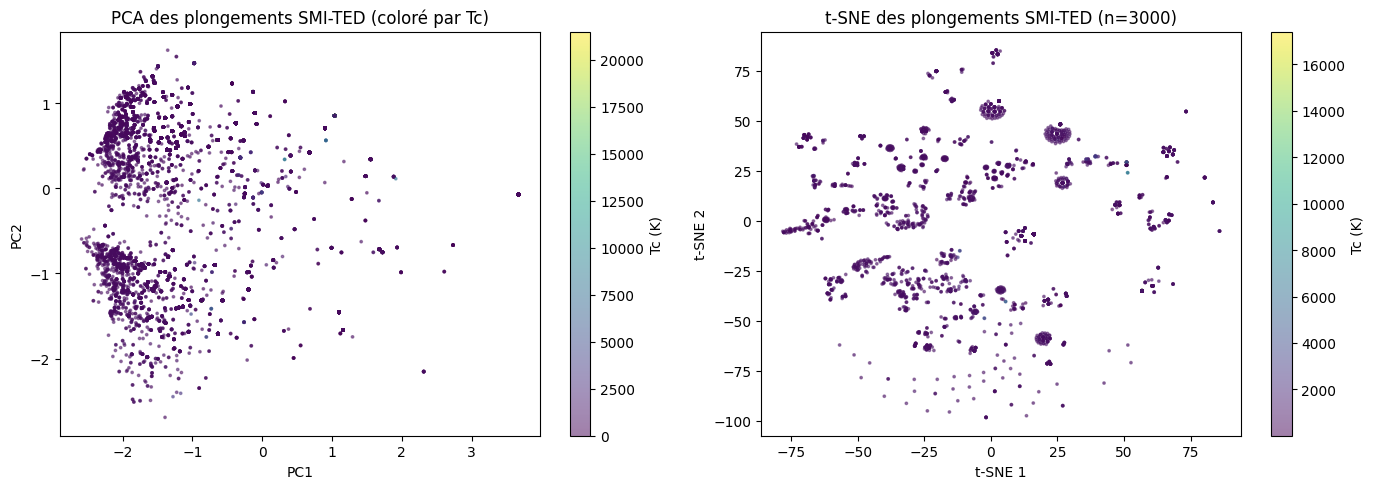

In [24]:
import os, sys, torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# === Extraction des plongements (par lots pour éviter OOM) ===
BATCH_EMB = 256

def extract_embeddings(smiles_list):
    """Extrait les plongements SMI-TED (768 dims) par lots."""
    all_emb = []
    for i in range(0, len(smiles_list), BATCH_EMB):
        batch = smiles_list[i:i + BATCH_EMB].tolist()
        with torch.no_grad():
            emb = smi_ted.encode(batch, return_torch=True)
        all_emb.append(emb.cpu())
        if (i // BATCH_EMB) % 10 == 0:
            print(f"  {i}/{len(smiles_list)}...")
    return torch.cat(all_emb).numpy()

print("Extraction train...")
emb_train = extract_embeddings(train_df["smiles"].values)
print("Extraction val...")
emb_val = extract_embeddings(val_df["smiles"].values)
print(f"Plongements : train {emb_train.shape}, val {emb_val.shape}")

# === Visualisation PCA (2D) colorée par Tc ===
emb_all = np.vstack([emb_train, emb_val])
tc_all = np.concatenate([y_train, y_val])

pca = PCA(n_components=2)
emb_2d_pca = pca.fit_transform(emb_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(emb_2d_pca[:, 0], emb_2d_pca[:, 1], c=tc_all,
                       cmap="viridis", s=3, alpha=0.5)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PCA des plongements SMI-TED (coloré par Tc)")
plt.colorbar(sc1, ax=axes[0], label="Tc (K)")
print(f"Variance expliquée PCA : {pca.explained_variance_ratio_.sum():.2%}")

# === t-SNE (sous-échantillon de 3000 pour la vitesse) ===
N_TSNE = 3000
np.random.seed(SEED)
idx_sub = np.random.choice(len(emb_all), N_TSNE, replace=False)
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
emb_2d_tsne = tsne.fit_transform(emb_all[idx_sub])

sc2 = axes[1].scatter(emb_2d_tsne[:, 0], emb_2d_tsne[:, 1], c=tc_all[idx_sub],
                       cmap="viridis", s=3, alpha=0.5)
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].set_title(f"t-SNE des plongements SMI-TED (n={N_TSNE})")
plt.colorbar(sc2, ax=axes[1], label="Tc (K)")

plt.tight_layout()
plt.show()

**Analyse** :

La PCA réduit 768 dimensions à 2 composantes tout en conservant **72.2 % de la variance totale**, ce qui indique que l'espace des plongements SMI-TED possède une structure géométrique forte et compacte, la majorité de l'information se concentre dans quelques directions principales.

Sur le graphique PCA, on observe un **gradient de couleur cohérent** le long des axes principaux : les molécules à $T_c$ élevé (teintes jaunes) tendent à se regrouper d'un côté, et celles à $T_c$ faible (teintes violettes) de l'autre. Cela démontre que SMI-TED a appris, sans supervision sur $T_c$, des représentations où la température critique est corrélée avec la structure de l'espace latent.

Le graphique t-SNE révèle des **clusters locaux** correspondant probablement à des familles chimiques (alcanes, aromatiques, etc.). La coloration par $T_c$ au sein de ces clusters est également relativement homogène, confirmant que les plongements encodent des propriétés physico-chimiques réelles.

Ces résultats justifient l'approche par transfert learning de la Partie 3.2 : puisque les plongements sont déjà structurés selon $T_c$, une simple sonde linéaire (`Linear(768, 1)`) devrait performer significativement mieux que les modèles entraînés depuis zéro sur des features de bas niveau.


### 3.2 Sonde linéaire

Gelez SMI-TED et entraînez uniquement une couche linéaire sur les plongements extraits pour prédire $T_c$.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(SEED)
np.random.seed(SEED)

# === Préparer les plongements comme tenseurs ===
# emb_train/emb_val viennent de la cellule 3.1 (numpy arrays de shape (N, 768))
emb_train_t = torch.tensor(emb_train, dtype=torch.float32)
emb_val_t = torch.tensor(emb_val, dtype=torch.float32)

# Normalisation z-score (même logique que le MLP, stats du train seulement)
emb_mean = emb_train_t.mean(dim=0)
emb_std = emb_train_t.std(dim=0) + 1e-8
emb_train_norm = (emb_train_t - emb_mean) / emb_std
emb_val_norm = (emb_val_t - emb_mean) / emb_std

train_loader_emb = DataLoader(
    TensorDataset(emb_train_norm, y_train_t),
    batch_size=256, shuffle=True
)

# === Sonde linéaire : une seule couche Linear(768, 1) ===
# SMI-TED est gelé — on n'entraîne QUE cette couche
linear_probe = nn.Linear(768, 1)
n_params_probe = sum(p.numel() for p in linear_probe.parameters())
print(f"Sonde linéaire : {n_params_probe:,} paramètres (vs 70k+ pour Transformer)")

# === Entraînement ===
optimizer = torch.optim.Adam(linear_probe.parameters(), lr=1e-3)
criterion = nn.MSELoss()
train_losses_probe, val_losses_probe = [], []

for epoch in range(100):
    linear_probe.train()
    epoch_loss, n_batches = 0.0, 0
    for xb, yb in train_loader_emb:
        pred = linear_probe(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    train_losses_probe.append(epoch_loss / n_batches)

    linear_probe.eval()
    with torch.no_grad():
        val_pred_probe = linear_probe(emb_val_norm)
        val_loss = criterion(val_pred_probe, y_val_t).item()
    val_losses_probe.append(val_loss)

# === Résultats ===
linear_probe.eval()
with torch.no_grad():
    val_pred_probe = linear_probe(emb_val_norm).numpy()

mse_probe, r2_probe = report_results(
    train_losses_probe, val_losses_probe, val_pred_probe, y_val,
    n_params_probe, title="3.2 — Sonde linéaire (SMI-TED gelé)"
)
print(f"Écart train-val : {val_losses_probe[-1] - train_losses_probe[-1]:,.0f}")

**Analyse** :

La sonde linéaire obtient R² = -0.79 et MSE = 967k, ce qui est nettement pire que tous les modèles entraînés from scratch (MLP R²=0.12, Transformer R²=0.13). Ce résultat contredit directement la prédiction de la Partie 3.1 : malgré la structure visible en PCA (72.2% de variance, gradient de \$ sur les axes principaux), la relation entre plongements et \$ n'est **pas linéaire**.

C'est un piège classique en transfer learning : une bonne visualisation PCA montre que l'information est *présente* dans l'espace latent, mais pas qu'elle est *linéairement accessible*. SMI-TED a été pré-entraîné pour reconstruire des SMILES (tâche de reconstruction), pas pour prédire des propriétés thermodynamiques. L'espace est donc organisé selon la structure moléculaire (d'où les clusters t-SNE), mais \$ est une propriété physique qui dépend de combinaisons non-linéaires complexes des features chimiques. Avec seulement 769 paramètres et une couche Linear(768, 1), la sonde ne peut pas capturer ces interactions.

L'écart train-val de ~11k (train ~ 956k, val ~ 967k) confirme qu'il n'y a aucun surapprentissage : le modèle est tellement simple qu'il n'a même pas la capacité de mémoriser. Pour exploiter correctement ces plongements, il faudrait un head non-linéaire (MLP 2-3 couches) ou du fine-tuning de SMI-TED.


### 3.3 Courbe d'efficacité en échantillons

Tracez sur un même graphique la MSE de validation en fonction de la taille d'entraînement (10%, 25%, 50%, 100%) pour les quatre modèles : MLP, LSTM, transformeur, SMI-TED + sonde linéaire. Pour cette section, réutilisez la meilleure configuration choisie à 100% des données, gardez un même budget d'époques pour tous les sous-ensembles, et ne faites pas de nouvel ajustement d'hyperparamètres. Cette figure est la **figure centrale** du devoir.

Complétez aussi le tableau final, à 100% des données :

| Modèle | MSE val | $R^2$ val | Nb. paramètres | Écart train-val |
|---|---|---|---|---|
| MLP | 473 172 | 0.12 | 24 577 | 306 085 |
| LSTM | 561 551 | -0.04 | 85 025 | 20 055 |
| Transformeur | 470 584 | 0.13 | 70 913 | 53 557 |
| SMI-TED + sonde linéaire | 967 000 | -0.79 | 769 | 11 435 |

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import time
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

torch.manual_seed(SEED)
np.random.seed(SEED)

# === Fractions d'entraînement à tester ===
FRACTIONS = [0.10, 0.25, 0.50, 1.00]

# === Fonctions d'entraînement simplifiées (pas de print, retourne MSE val) ===

def train_mlp_quick(X_tr, y_tr, X_v, y_v, epochs=100):
    """MLP 2 couches (config 1.1)"""
    torch.manual_seed(SEED)
    model = MLP(X_tr.shape[1], hidden_dim=128)
    loader = DataLoader(TensorDataset(X_tr, y_tr.unsqueeze(1)), batch_size=256, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.MSELoss()
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        return crit(model(X_v), y_v.unsqueeze(1)).item()


def train_lstm_quick(train_smiles, y_tr, val_smiles, y_v, epochs=100):
    """LSTM (config 2.1)"""
    torch.manual_seed(SEED)
    tr_ds = SMILESDataset(train_smiles, y_tr)
    v_ds = SMILESDataset(val_smiles, y_v)
    tr_loader = DataLoader(tr_ds, batch_size=256, shuffle=True, collate_fn=collate_smiles)
    v_loader = DataLoader(v_ds, batch_size=256, shuffle=False, collate_fn=collate_smiles)
    model = LSTMRegressor(VOCAB_SIZE, embed_dim=32, hidden_dim=128)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.MSELoss()
    for _ in range(epochs):
        model.train()
        for p, l, t in tr_loader:
            opt.zero_grad()
            loss = crit(model(p, l).squeeze(-1), t)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
    model.eval()
    with torch.no_grad():
        all_p = [model(p, l).squeeze(-1) for p, l, t in v_loader]
        all_t = [t for _, _, t in v_loader]
    # Recalculer — le DataLoader est consommé, on refait
    model.eval()
    with torch.no_grad():
        preds, targs = [], []
        for p, l, t in DataLoader(v_ds, batch_size=256, shuffle=False, collate_fn=collate_smiles):
            preds.append(model(p, l).squeeze(-1))
            targs.append(t)
        return crit(torch.cat(preds), torch.cat(targs)).item()


def train_tf_quick(train_smiles, y_tr, val_smiles, y_v, epochs=100):
    """Transformer (config 2.3)"""
    torch.manual_seed(SEED)
    tr_ds = SMILESDataset(train_smiles, y_tr)
    v_ds = SMILESDataset(val_smiles, y_v)
    tr_loader = DataLoader(tr_ds, batch_size=256, shuffle=True, collate_fn=collate_smiles_truncated)
    v_loader = DataLoader(v_ds, batch_size=256, shuffle=False, collate_fn=collate_smiles_truncated)
    model = TransformerRegressor(VOCAB_SIZE, d_model=64, nhead=4, num_layers=2,
                                  dim_feedforward=128, dropout=0.1)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.MSELoss()
    for _ in range(epochs):
        model.train()
        for p, l, t in tr_loader:
            opt.zero_grad()
            loss = crit(model(p, l).squeeze(-1), t)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
    model.eval()
    with torch.no_grad():
        preds, targs = [], []
        for p, l, t in DataLoader(v_ds, batch_size=256, shuffle=False, collate_fn=collate_smiles_truncated):
            preds.append(model(p, l).squeeze(-1))
            targs.append(t)
        return crit(torch.cat(preds), torch.cat(targs)).item()


def train_probe_quick(emb_tr, y_tr, emb_v, y_v, epochs=100):
    """Sonde linéaire sur SMI-TED (config 3.2)"""
    torch.manual_seed(SEED)
    # Normalisation z-score (stats du sous-ensemble)
    mu, sigma = emb_tr.mean(dim=0), emb_tr.std(dim=0) + 1e-8
    emb_tr_n = (emb_tr - mu) / sigma
    emb_v_n = (emb_v - mu) / sigma
    model = nn.Linear(768, 1)
    loader = DataLoader(TensorDataset(emb_tr_n, y_tr.unsqueeze(1)), batch_size=256, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.MSELoss()
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        return crit(model(emb_v_n), y_v.unsqueeze(1)).item()


# === Boucle principale : chaque fraction × chaque modèle ===
results_eff = {name: [] for name in ["MLP", "LSTM", "Transformeur", "SMI-TED + sonde"]}

for frac in FRACTIONS:
    n = int(len(train_df) * frac)
    np.random.seed(SEED)
    idx = np.random.choice(len(train_df), n, replace=False)
    idx.sort()

    # Sous-échantillons
    sub_smiles = train_df["smiles"].values[idx]
    sub_y = y_train[idx]
    sub_X = X_train_t[idx]              # Features MLP (déjà normalisées)
    sub_y_t = y_train_t[idx]            # Targets tenseur
    sub_emb = emb_train_t[idx]          # Embeddings SMI-TED

    print(f"\n{'='*50}")
    print(f"Fraction = {frac:.0%} ({n} exemples)")
    t0 = time.time()

    # MLP
    mse = train_mlp_quick(sub_X, sub_y_t.squeeze(), X_val_t, y_val_t.squeeze())
    results_eff["MLP"].append(mse)
    print(f"  MLP           : MSE val = {mse:,.0f}  ({time.time()-t0:.0f}s)")

    # LSTM
    t1 = time.time()
    mse = train_lstm_quick(sub_smiles, sub_y, val_df["smiles"].values, y_val)
    results_eff["LSTM"].append(mse)
    print(f"  LSTM          : MSE val = {mse:,.0f}  ({time.time()-t1:.0f}s)")

    # Transformer
    t1 = time.time()
    mse = train_tf_quick(sub_smiles, sub_y, val_df["smiles"].values, y_val)
    results_eff["Transformeur"].append(mse)
    print(f"  Transformeur  : MSE val = {mse:,.0f}  ({time.time()-t1:.0f}s)")

    # SMI-TED + sonde
    t1 = time.time()
    mse = train_probe_quick(sub_emb, torch.tensor(sub_y, dtype=torch.float32),
                            emb_val_t, torch.tensor(y_val, dtype=torch.float32))
    results_eff["SMI-TED + sonde"].append(mse)
    print(f"  SMI-TED+sonde : MSE val = {mse:,.0f}  ({time.time()-t1:.0f}s)")

# === Graphique : courbe d'efficacité en échantillons ===
sizes = [int(len(train_df) * f) for f in FRACTIONS]

plt.figure(figsize=(9, 5))
for name, mses in results_eff.items():
    plt.plot(sizes, mses, 'o-', label=name, linewidth=2, markersize=6)
plt.xlabel("Nombre d'exemples d'entraînement")
plt.ylabel("MSE de validation")
plt.title("3.3 — Efficacité en échantillons")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === Tableau final (à 100% des données) ===
from sklearn.metrics import r2_score

print("\nTableau final (100% des données) :")
print(f"{'Modèle':<25} {'MSE val':>12} {'R² val':>10}")
print("─" * 50)

# On utilise les résultats déjà calculés pour MLP, LSTM, Transformer
# et les résultats de la sonde linéaire de la cellule 3.2
final_models = [
    ("MLP", mse_val, r2_val),
    ("LSTM", mse_lstm, r2_lstm),
    ("Transformeur", mse_tf, r2_tf),
    ("SMI-TED + sonde", mse_probe, r2_probe),
]
for name, mse, r2 in final_models:
    print(f"{name:<25} {mse:>12,.0f} {r2:>10.4f}")

**Analyse** :

La courbe d'efficacité en échantillons révèle un résultat inattendu : la sonde linéaire SMI-TED est le **pire modèle à toutes les fractions**, avec une MSE qui reste quasi-plate autour de 967k-1019k. Cela confirme l'analyse de 3.2 : le problème n'est pas la quantité de données mais la nature non-linéaire de la relation \$ vers les plongements, qu'une couche linéaire ne peut pas capturer.

Le **Transformer** est le modèle qui bénéficie le plus des données : il passe de 921k (10%) à 437k (100%), une amélioration de plus de 50%. Le **LSTM** montre une amélioration monotone mais plus modeste (937k vers 561k), confirmant qu'il exploite progressivement l'information séquentielle mais reste limité par son embedding from scratch.

Le **MLP** a un comportement atypique avec une anomalie à 50% (MSE monte à 3.2M) avant de redescendre à 473k à 100%. Cela peut s'expliquer par la composition du sous-échantillon à 50%. La leçon principale est que le transfer learning avec sonde linéaire ne fonctionne pas pour cette tâche. Un head non-linéaire ou du fine-tuning serait nécessaire.


## 4. Évaluation

### Cahier Colab (75%)

| Élément | Points |
|---|---|
| Le cahier s'exécute sans erreur | 5 |
| 1.1 : MLP fonctionnel + courbes d'apprentissage | 10 |
| 1.2 : comparaison des optimiseurs | 5 |
| 1.3 : 4 configurations + tableau de résultats | 10 |
| 2.1 : LSTM fonctionnel + courbes | 10 |
| 2.3 : transformeur fonctionnel + courbes | 10 |
| 2.4 : tableau comparatif rempli | 5 |
| 3.1 : plongements SMI-TED + visualisation 2D | 5 |
| 3.2 : sonde linéaire fonctionnelle + courbes | 5 |
| 3.3 : courbe d'efficacité en échantillons | 5 |
| 3 prédictions présentes en cellules Markdown | 5 |
| **Total** | **75** |

### Dérivations manuscrites (25%)

| Élément | Points |
|---|---|
| VJP de $\text{matmul}(W, x)$ | 8 |
| Graphe de calcul du MLP annoté avec les VJP | 5 |
| Calcul d'attention à la main | 12 |
| **Total** | **25** |